In [1]:
import ee
import geemap

# Initialize Earth Engine if not already running
ee.Initialize(project="ee-shahlankabir")

# Define your exact target ROI
roi = ee.FeatureCollection("FAO/GAUL/2015/level2") \
        .filter(ee.Filter.eq('ADM2_NAME', 'Comilla'))

# Save it to your local workspace directory
local_roi_path = "boundary.geojson"
geemap.ee_to_geojson(roi, filename=local_roi_path)

print(f"🎯 Boundary vector successfully downloaded locally to: '{local_roi_path}'")

🎯 Boundary vector successfully downloaded locally to: 'boundary.geojson'


In [2]:
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.mask import mask

full_lulc_path = "lulc1.tif"
clipped_lulc_path = "Clipped_LULC.tif"
default_background = 255 # Custom clean NoData value for outer boundary space

# 1. Load the local GeoJSON we extracted in Step 1
gdf_roi = gpd.read_file(local_roi_path)

print("✂️ Beginning clipping execution sequence...")
with rasterio.open(full_lulc_path) as src:
    # Match spatial reference systems between layers dynamically
    if gdf_roi.crs != src.crs:
        print(f"🌐 Aligning projections: Transforming ROI to match raster CRS ({src.crs})")
        gdf_roi = gdf_roi.to_crs(src.crs)
        
    roi_geometries = gdf_roi.geometry.values
    
    # Extract the mask
    clipped_data, clipped_transform = mask(src, roi_geometries, crop=True, nodata=default_background)
    clipped_band = clipped_data[0]

    # Reconstruct geographic metadata header profile
    meta_update = src.meta.copy()
    meta_update.update({
        "driver": "GTiff",
        "height": clipped_band.shape[0],
        "width": clipped_band.shape[1],
        "transform": clipped_transform,
        "dtype": "uint8",
        "count": 1,
        "nodata": default_background
    })

# 2. Write the optimized clipped image matrix to disk
with rasterio.open(clipped_lulc_path, "w", **meta_update) as dst:
    dst.write(clipped_band.astype(np.uint8), 1)

print(f"🎉 Success! Your clipped map file is ready locally at: '{clipped_lulc_path}'")

✂️ Beginning clipping execution sequence...
🌐 Aligning projections: Transforming ROI to match raster CRS (EPSG:32646)
🎉 Success! Your clipped map file is ready locally at: 'Clipped_LULC.tif'


In [3]:
import numpy as np
import rasterio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- PATH TO DOWNLOADED LULC ---


print("🧐 Inspecting Raster Metadata and Contents...")
with rasterio.open(clipped_lulc_path) as src:
    print(f"📐 Dimensions: {src.width}x{src.height} pixels")
    print(f"🌐 Coordinate System (CRS): {src.crs}")
    print(f"🔢 Data Type: {src.dtypes[0]}")
    print(f"❌ Core NoData Value: {src.nodata}")
    
    # Read the data band
    lulc_array = src.read(1)

# Flatten the array and remove standard NoData or zero buffer values
flat_pixels = lulc_array.flatten()
cleaned_pixels = flat_pixels[flat_pixels != (src.nodata if src.nodata is not None else 0)]

# Count occurrences of each unique ID
unique_values, pixel_counts = np.unique(cleaned_pixels, return_counts=True)

# Build a dataframe to view percentages
df_stats = pd.DataFrame({
    'Class_ID': unique_values,
    'Pixel_Count': pixel_counts,
    'Percentage (%)': np.round((pixel_counts / len(cleaned_pixels)) * 100, 2)
})

print("\n📊 Unique Classification Values Found in Your File:")
print(df_stats.to_string(index=False))

🧐 Inspecting Raster Metadata and Contents...
📐 Dimensions: 7455x8304 pixels
🌐 Coordinate System (CRS): EPSG:32646
🔢 Data Type: uint8
❌ Core NoData Value: 255.0

📊 Unique Classification Values Found in Your File:
 Class_ID  Pixel_Count  Percentage (%)
        1      1312923            4.29
        2      3282086           10.72
        4       221497            0.72
        5     15542946           50.76
        7     10098974           32.98
        8         3868            0.01
       11       156205            0.51


C:\Users\santo\AppData\Local\Temp\ipykernel_5596\2416994518.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_classes)
c:\Users\santo\miniconda3\envs\geo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


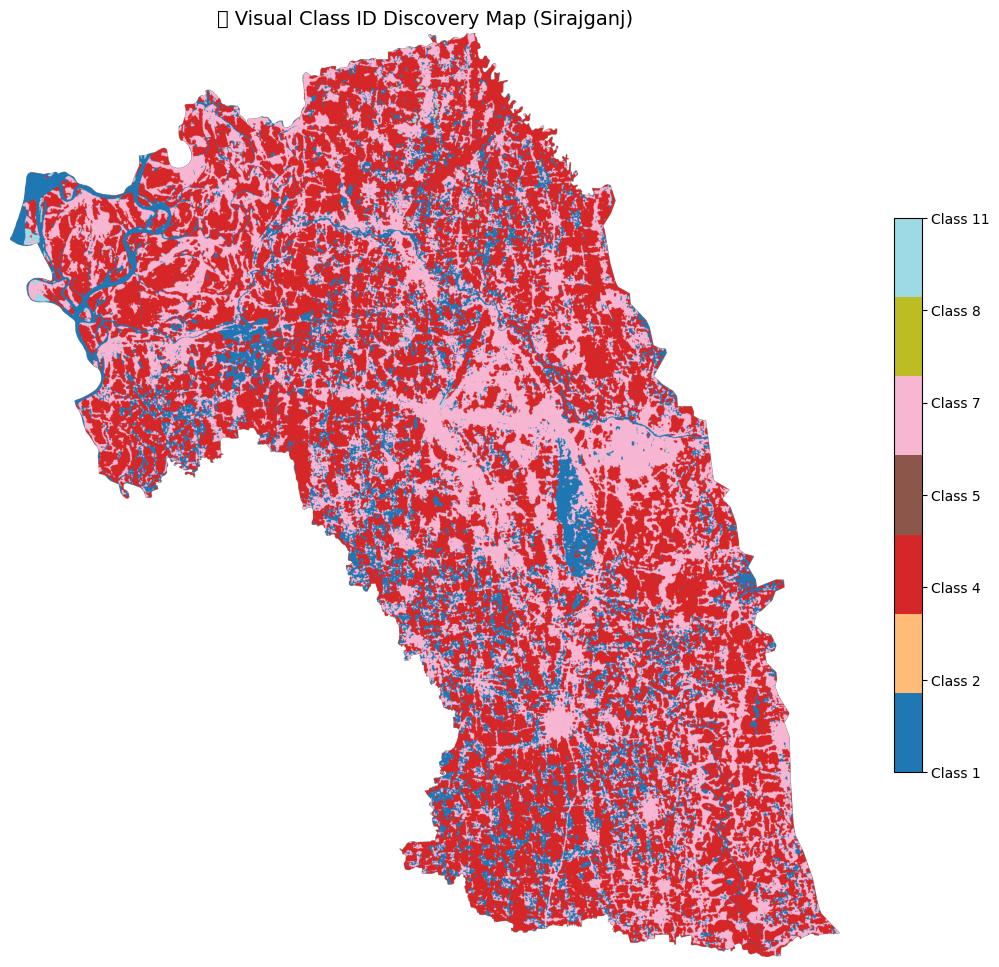

In [5]:
from matplotlib.colors import ListedColormap

# Get the list of unique IDs found from your previous cell's printout
# For example, if your df_stats showed: [10, 20, 30, 40, 50, 80, 90]
active_ids = list(df_stats['Class_ID'].values)
num_classes = len(active_ids)

# Generate a high-contrast color palette dynamically for exploration
colors = plt.cm.get_cmap('tab20', num_classes)
custom_cmap = ListedColormap(colors.colors)

# Mask the background NoData values (e.g., 255) so it doesn't skew our colors
default_background = src.nodata if src.nodata is not None else 255
masked_lulc = np.ma.masked_equal(lulc_array, default_background)

# Plot the visual map
plt.figure(figsize=(14, 12))
im = plt.imshow(masked_lulc, cmap=custom_cmap)

# Add an accurate discrete colorbar matching your specific IDs
cbar = plt.colorbar(im, ticks=np.linspace(masked_lulc.min(), masked_lulc.max(), num_classes), shrink=0.6)
cbar.ax.set_yticklabels([f"Class {int(uid)}" for uid in active_ids])

plt.title("📍 Visual Class ID Discovery Map (Sirajganj)", fontsize=14)
plt.axis('off')
plt.show()

In [6]:
final_output_path = "Standardized_LULC.tif"
export_nodata = 255

print("🔄 Executing reclassification logic across the array...")

# 1. Initialize a blank array filled with NoData markers (255)
reclassified_array = np.full(lulc_array.shape, export_nodata, dtype=np.uint8)

# 2. Extract all unique IDs found in your file dynamically from df_stats
active_ids = df_stats['Class_ID'].values

# 3. Apply your specific conditional rule layout
for original_id in active_ids:
    if original_id == 1:
        reclassified_array[lulc_array == original_id] = 0  # Waterbody -> 0
    elif original_id == 7:
        reclassified_array[lulc_array == original_id] = 2  # Built-up -> 2
    else:
        reclassified_array[lulc_array == original_id] = 1  # Everything else -> Vegetation (1)

# 4. Update the raster metadata headers for clean 8-bit single band output
with rasterio.open(clipped_lulc_path) as src:
    meta_profile = src.meta.copy()
    meta_profile.update({
        "driver": "GTiff",
        "dtype": "uint8",
        "count": 1,
        "nodata": export_nodata,
        "height": reclassified_array.shape[0],
        "width": reclassified_array.shape[1]
    })

# 5. Write the final standardized file to disk
with rasterio.open(final_output_path, "w", **meta_profile) as dst:
    dst.write(reclassified_array, 1)

print(f"💾 Standardized 3-class LULC map successfully created: '{final_output_path}'")

🔄 Executing reclassification logic across the array...
💾 Standardized 3-class LULC map successfully created: 'Standardized_LULC.tif'


c:\Users\santo\miniconda3\envs\geo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


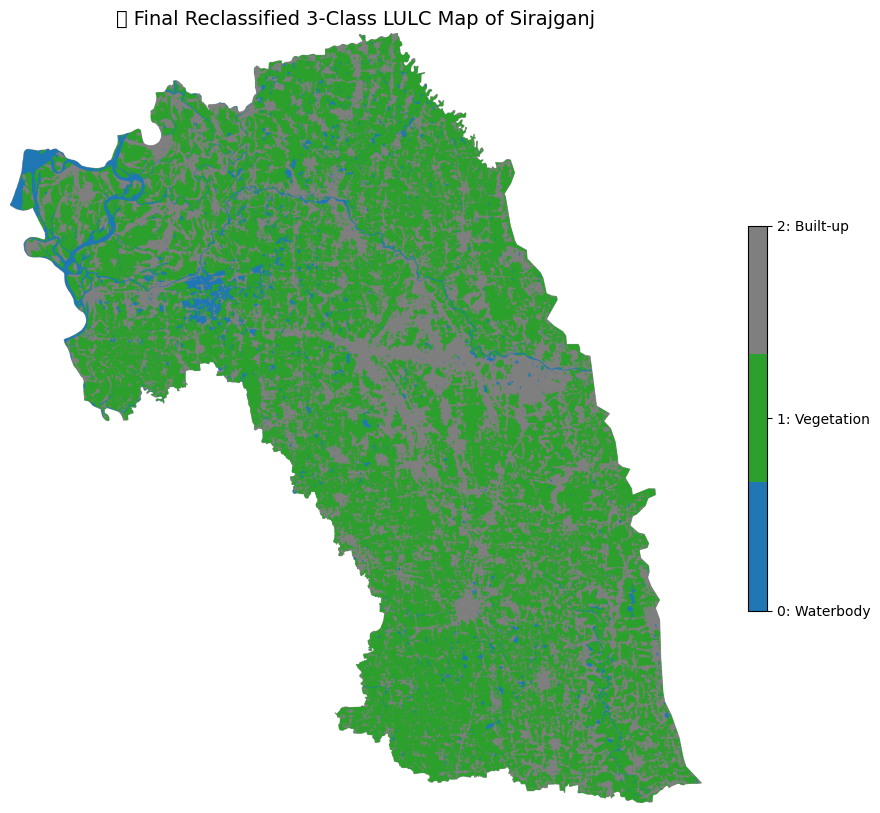

In [7]:
from matplotlib.colors import ListedColormap

# Setup target colors: 0 = Blue (Water), 1 = Green (Veg), 2 = Grey (Built-up)
final_colors = ListedColormap(['#1f77b4', '#2ca02c', '#7f7f7f'])

# Mask background values so they show as empty white canvas space
final_masked = np.ma.masked_equal(reclassified_array, export_nodata)

plt.figure(figsize=(12, 10))
plt.imshow(final_masked, cmap=final_colors, vmin=0, vmax=2)

# Generate a clean map legend
cbar = plt.colorbar(shrink=0.5, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['0: Waterbody', '1: Vegetation', '2: Built-up'])

plt.title("🎯 Final Reclassified 3-Class LULC Map of Sirajganj", fontsize=14)
plt.axis('off')
plt.show()

📂 Loading raster and vector layers...
🎨 Rendering map layers...
🎉 Publication-quality map saved as 'final_lulc_map.png'


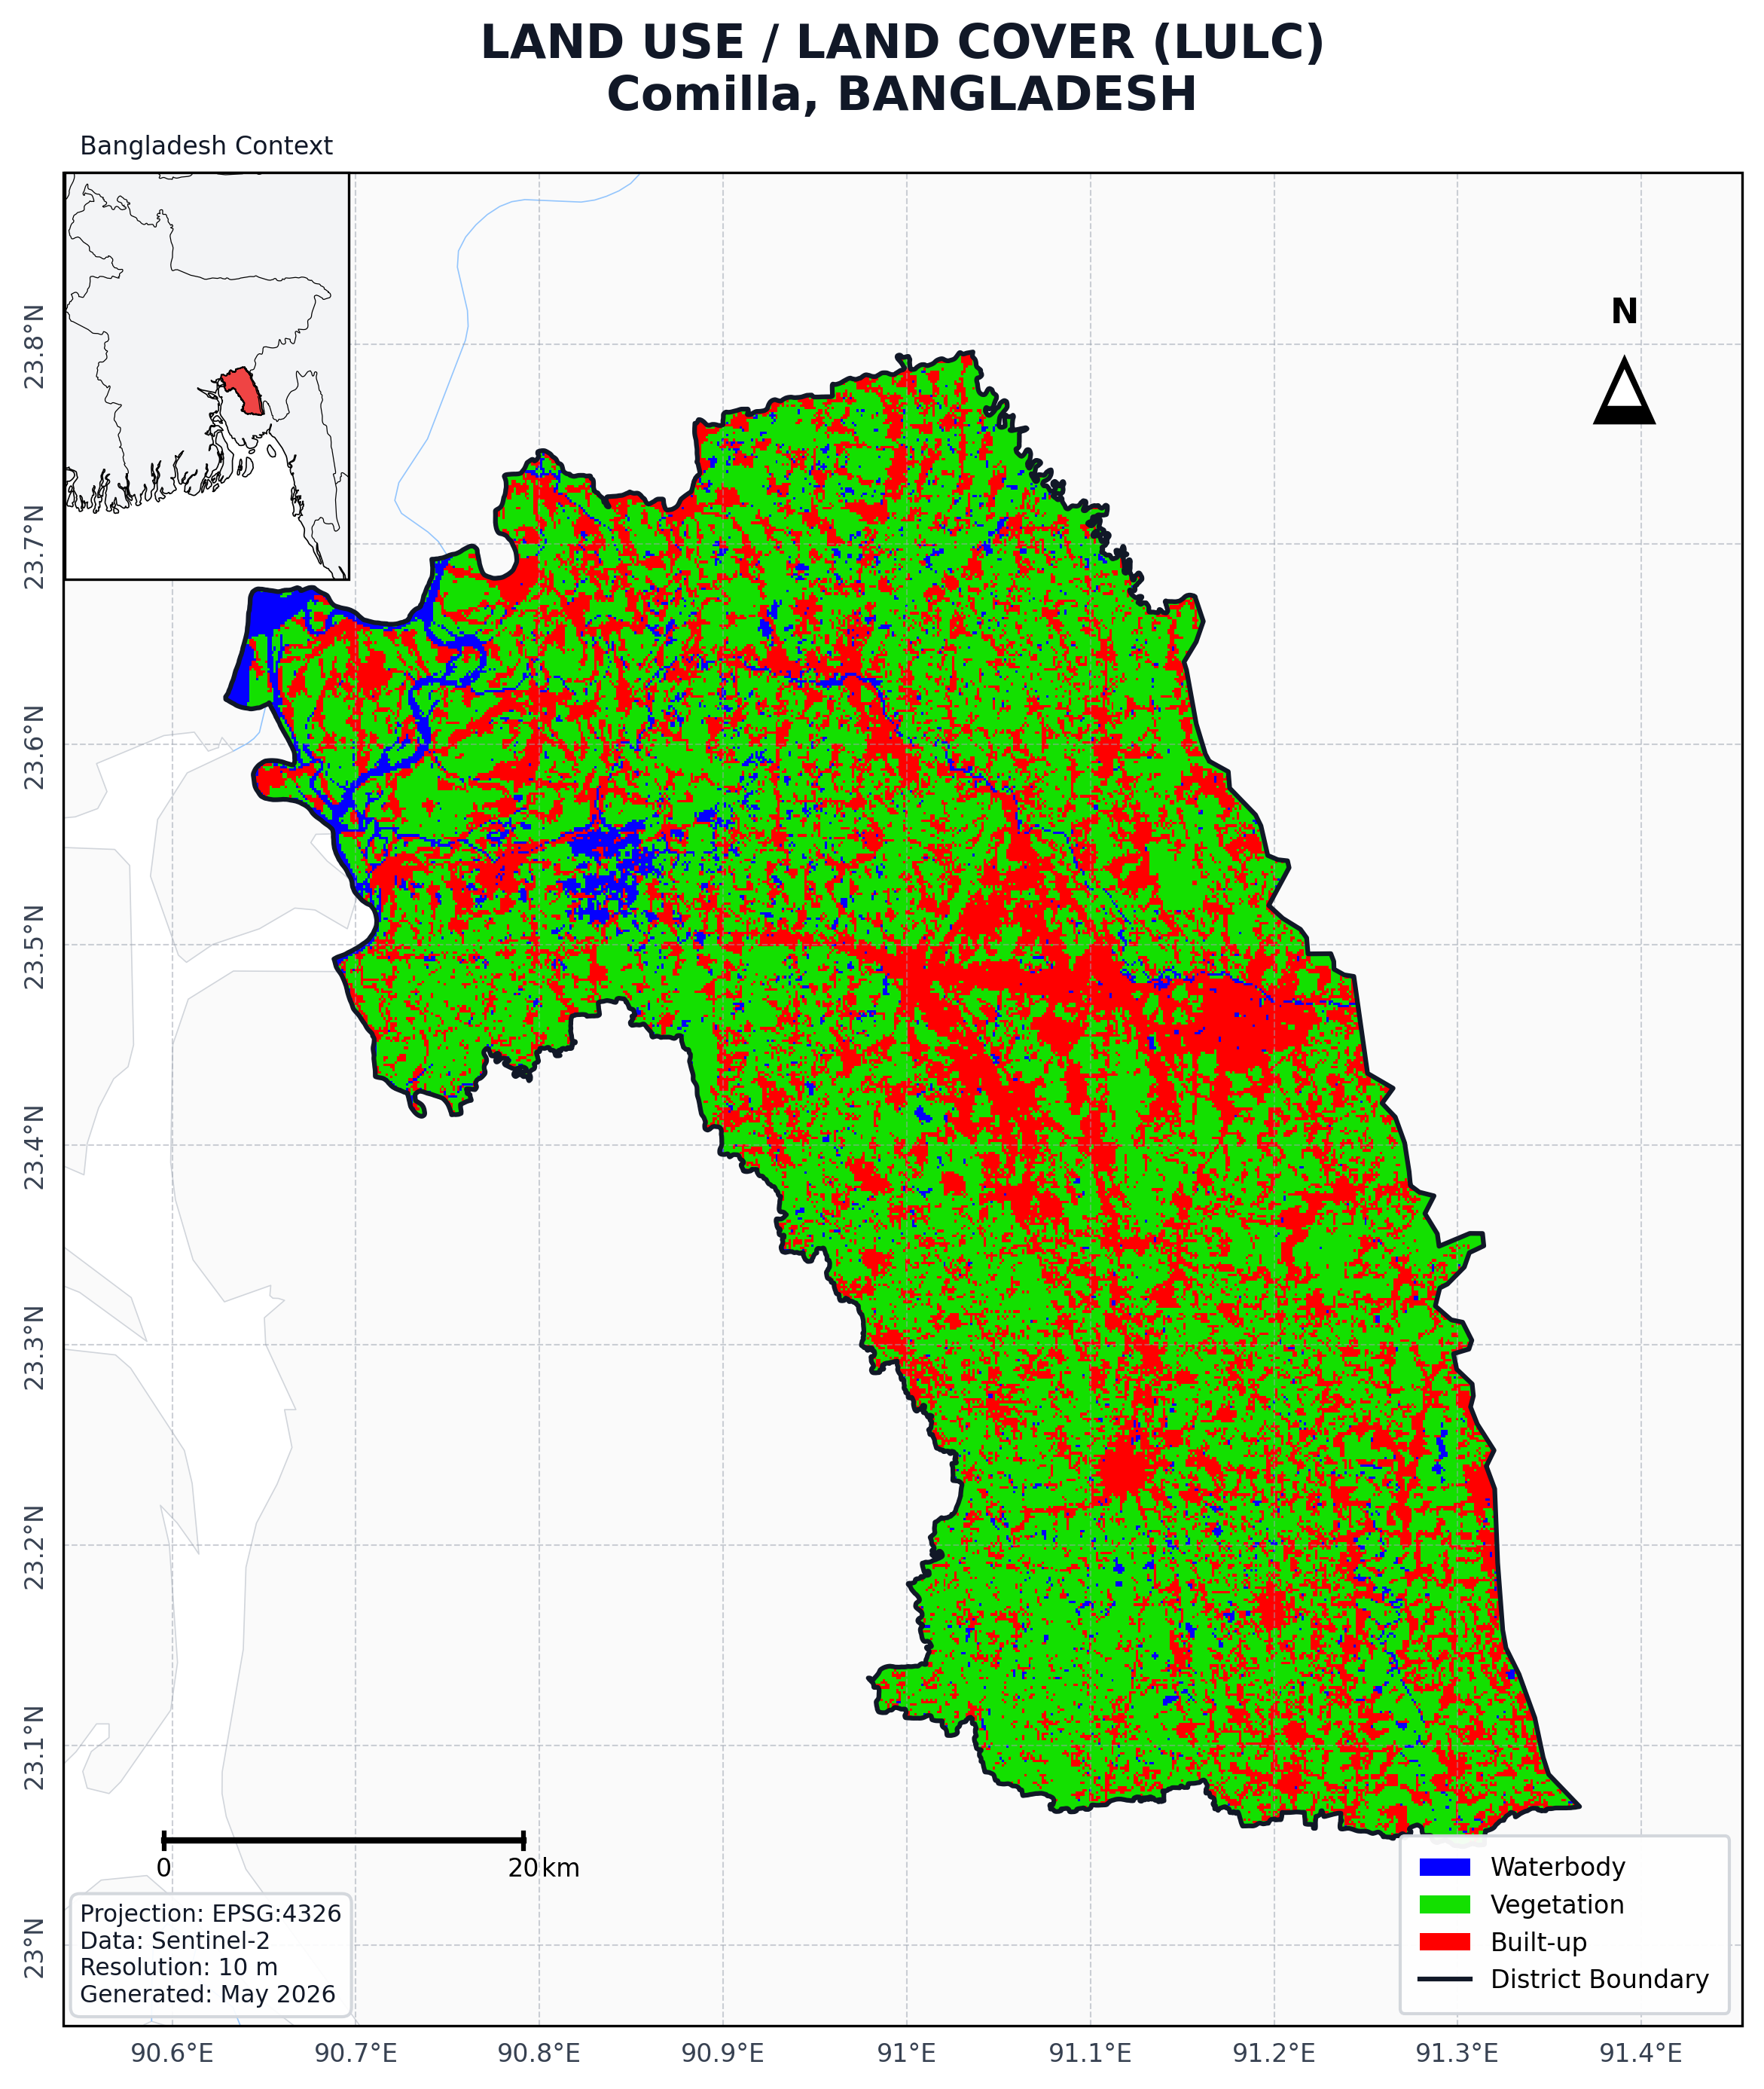

In [13]:
import numpy as np
import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from math import cos, radians

# =========================================================
# 1. FILE PATHS
# =========================================================
standardized_lulc_path = "Standardized_LULC.tif"
local_roi_path = "boundary.geojson"
output_image_path = "final_lulc_map.png"

export_nodata = 255

# =========================================================
# 2. LOAD DATA
# =========================================================
print("📂 Loading raster and vector layers...")

with rasterio.open(standardized_lulc_path) as src:

    lulc_array = src.read(1)
    raster_crs = src.crs
    raster_extent = plotting_extent(src)

mask_gdf = gpd.read_file(local_roi_path)

# =========================================================
# 3. REPROJECT VECTOR TO DISPLAY CRS
# =========================================================
mask_gdf = mask_gdf.to_crs("EPSG:4326")

# =========================================================
# 4. MAP PROJECTION & COLOR SCHEME
# =========================================================
map_proj = ccrs.PlateCarree()

# Improved professional thematic colors
lulc_colors = ListedColormap([
    "#0400FF",   # Water
    "#13E000",   # Vegetation
    "#FF0000"    # Built-up
])

masked_lulc = np.ma.masked_equal(
    lulc_array,
    export_nodata
)

# =========================================================
# 5. FIGURE & LAYOUT
# =========================================================
fig = plt.figure(
    figsize=(11, 10),
    dpi=300
)

ax = fig.add_axes(
    [0.08, 0.08, 0.78, 0.82],
    projection=map_proj
)

# =========================================================
# 6. DYNAMIC EXTENT
# =========================================================
xmin, ymin, xmax, ymax = mask_gdf.total_bounds

x_pad = (xmax - xmin) * 0.12
y_pad = (ymax - ymin) * 0.12

display_extent = [
    xmin - x_pad,
    xmax + x_pad,
    ymin - y_pad,
    ymax + y_pad
]

ax.set_extent(
    display_extent,
    crs=ccrs.PlateCarree()
)

# =========================================================
# 7. BASEMAP
# =========================================================
ax.add_feature(
    cfeature.LAND,
    facecolor="#FAFAFA",
    edgecolor="#D1D5DB",
    linewidth=0.4,
    zorder=0
)

ax.add_feature(
    cfeature.RIVERS,
    edgecolor="#93C5FD",
    linewidth=0.4,
    zorder=0
)

# =========================================================
# 8. RASTER TRANSFORM
# =========================================================
print("🎨 Rendering map layers...")

epsg_code = raster_crs.to_epsg()

if epsg_code == 4326 or epsg_code is None:
    raster_transform = ccrs.PlateCarree()
else:
    raster_transform = ccrs.epsg(epsg_code)

# =========================================================
# 9. PLOT RASTER
# =========================================================
ax.imshow(
    masked_lulc,
    cmap=lulc_colors,
    extent=raster_extent,
    transform=raster_transform,
    interpolation='none',
    vmin=0,
    vmax=2,
    zorder=1
)

# =========================================================
# 10. DISTRICT BOUNDARY
# =========================================================
mask_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#111827",
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# =========================================================
# 11. DYNAMIC GRIDLINES
# =========================================================
width = xmax - xmin

if width < 0.8:
    grid_interval = 0.1
elif width < 1.5:
    grid_interval = 0.2
else:
    grid_interval = 0.5

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='#9CA3AF',
    alpha=0.5,
    linestyle='--',
    xlocs=np.arange(-180, 180, grid_interval),
    ylocs=np.arange(-90, 90, grid_interval)
)

gl.top_labels = False
gl.right_labels = False

# Bottom longitude labels
gl.xlabel_style = {
    'size': 8,
    'color': '#374151'
}

# Left latitude labels
gl.ylabel_style = {
    'size': 8,
    'color': '#374151',
    'rotation': 90
}

# =========================================================
# 12. TITLE
# =========================================================
district_name = (
    local_roi_path
    .split(".")[0]
    .replace("_", " ")
    .upper()
)

plt.title(
    f"LAND USE / LAND COVER (LULC)\n"
    f"Comilla, BANGLADESH",
    fontsize=15,
    fontweight='bold',
    pad=20,
    color="#111827"
)

# =========================================================
# 13. MODERN NORTH ARROW
# =========================================================
def add_north_arrow(ax):

    x = 0.93
    y = 0.90
    size = 0.035

    triangle = Polygon(
        [
            [x, y],
            [x - size/2, y - size],
            [x + size/2, y - size]
        ],
        closed=True,
        facecolor='black',
        edgecolor='black',
        transform=ax.transAxes,
        zorder=20
    )

    inner_triangle = Polygon(
        [
            [x, y - 0.008],
            [x - size/4, y - size + 0.01],
            [x + size/4, y - size + 0.01]
        ],
        closed=True,
        facecolor='white',
        edgecolor='white',
        transform=ax.transAxes,
        zorder=21
    )

    ax.add_patch(triangle)
    ax.add_patch(inner_triangle)

    ax.text(
        x,
        y + 0.015,
        "N",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

add_north_arrow(ax)

# =========================================================
# 14. SCALE BAR
# =========================================================
def add_accurate_scale_bar(ax, extent, dist_km=10):

    lon_min, lon_max, lat_min, lat_max = extent

    avg_lat = (lat_min + lat_max) / 2

    km_per_degree = 111.32 * cos(radians(avg_lat))

    scale_width_deg = dist_km / km_per_degree

    x_start = lon_min + (lon_max - lon_min) * 0.06
    y_pos = lat_min + (lat_max - lat_min) * 0.10

    # Main line
    ax.plot(
        [x_start, x_start + scale_width_deg],
        [y_pos, y_pos],
        transform=ccrs.PlateCarree(),
        color='black',
        lw=2,
        zorder=20
    )

    # Ticks
    for x in [x_start, x_start + scale_width_deg]:

        ax.plot(
            [x, x],
            [y_pos - 0.004, y_pos + 0.004],
            transform=ccrs.PlateCarree(),
            color='black',
            lw=1.5,
            zorder=20
        )

    # Labels
    ax.text(
        x_start,
        y_pos - 0.008,
        "0",
        transform=ccrs.PlateCarree(),
        ha='center',
        va='top',
        fontsize=8
    )

    ax.text(
        x_start + scale_width_deg,
        y_pos - 0.008,
        f"{dist_km}",
        transform=ccrs.PlateCarree(),
        ha='center',
        va='top',
        fontsize=8
    )

    ax.text(
        x_start + scale_width_deg + 0.01,
        y_pos - 0.008,
        "km",
        transform=ccrs.PlateCarree(),
        ha='left',
        va='top',
        fontsize=8
    )

district_width_km = (xmax - xmin) * 111

if district_width_km < 40:
    scale_km = 5
elif district_width_km < 80:
    scale_km = 10
else:
    scale_km = 20

add_accurate_scale_bar(
    ax,
    display_extent,
    dist_km=scale_km
)

# =========================================================
# 15. LEGEND
# =========================================================
legend_elements = [

    plt.Rectangle(
        (0, 0), 1, 1,
        fc="#0400FF",
        label="Waterbody"
    ),

    plt.Rectangle(
        (0, 0), 1, 1,
        fc="#13E000",
        label="Vegetation"
    ),

    plt.Rectangle(
        (0, 0), 1, 1,
        fc="#FF0000",
        label="Built-up"
    ),

    Line2D(
        [0], [0],
        color='#111827',
        lw=1.5,
        label='District Boundary'
    )
]

legend = ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=8,
    frameon=True,
    borderpad=0.8
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('#D1D5DB')

# =========================================================
# 16. METADATA BOX
# =========================================================
ax.text(
    0.01,
    0.01,
    "Projection: EPSG:4326\n"
    "Data: Sentinel-2\n"
    "Resolution: 10 m\n"
    "Generated: May 2026",
    transform=ax.transAxes,
    fontsize=7.5,
    ha='left',
    va='bottom',
    color='#111827',
    bbox=dict(
        facecolor='white',
        alpha=0.92,
        edgecolor='#D1D5DB',
        boxstyle='round,pad=0.4'
    )
)

# =========================================================
# 17. INSET MAP
# =========================================================
inset_ax = fig.add_axes(
    [0.10, 0.72, 0.18, 0.18],
    projection=ccrs.PlateCarree()
)

inset_ax.add_feature(
    cfeature.LAND,
    facecolor="#F3F4F6"
)

inset_ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.4
)

inset_ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.3
)

mask_gdf.plot(
    ax=inset_ax,
    color='#EF4444',
    edgecolor='black',
    linewidth=0.5,
    transform=ccrs.PlateCarree()
)

inset_ax.set_extent(
    [88.0, 92.8, 20.5, 26.8],
    crs=ccrs.PlateCarree()
)

inset_ax.set_xticks([])
inset_ax.set_yticks([])

inset_ax.set_title(
    "Bangladesh Context",
    fontsize=8,
    color="#111827"
)

# =========================================================
# 18. SAVE MAP
# =========================================================
plt.savefig(
    output_image_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    f"🎉 Publication-quality map saved as "
    f"'{output_image_path}'"
)

plt.show()

In [ ]:
# =========================================================
# 16. SAVE FINAL MAP EXPORT (FIXED OBJECT-ORIENTED EXPORT)
# =========================================================
output_pdf_path = "lulc_cumilla.pdf"

# CRITICAL FIX: Use 'fig.savefig' instead of 'plt.savefig'
# This forces python to grab the specific 'fig' object we created in Section 5
fig.savefig(output_pdf_path, format="pdf", bbox_inches="tight", dpi=300)

print(f"🎉 Success! The map has been hard-saved to your directory as '{output_pdf_report if 'output_pdf_report' in locals() else output_pdf_path}'")

# Show the interactive plot window last
plt.show()

🎉 Success! The map has been hard-saved to your directory as 'nazmul_a05.pdf'
